In [1]:
import pandas as pd
import plotnine as p9
import numpy as np
import scanpy as sc

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mplpatches

In [3]:
p9.options.dpi=300
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype']='none'

In [5]:
df_10x_3pRNA=pd.read_csv(data_dir+'/barnyard_10x/exon_intron_nUMI_summary.csv',header=0)

In [6]:
df_10x_3pRNA['experiment']='Chromium'

In [7]:
df_OAK150k=pd.read_csv(data_dir+'/barnyard_OAK150kali1/exon_intron_nUMI_summary.csv',header=0)

In [8]:
df_OAK150k['experiment']='OAK'

In [9]:
df_3pRNA_compare=pd.concat([df_10x_3pRNA,df_OAK150k],ignore_index=True)

In [10]:
df_3pRNA_compare['intron_frac']=df_3pRNA_compare['intron_pct']*100

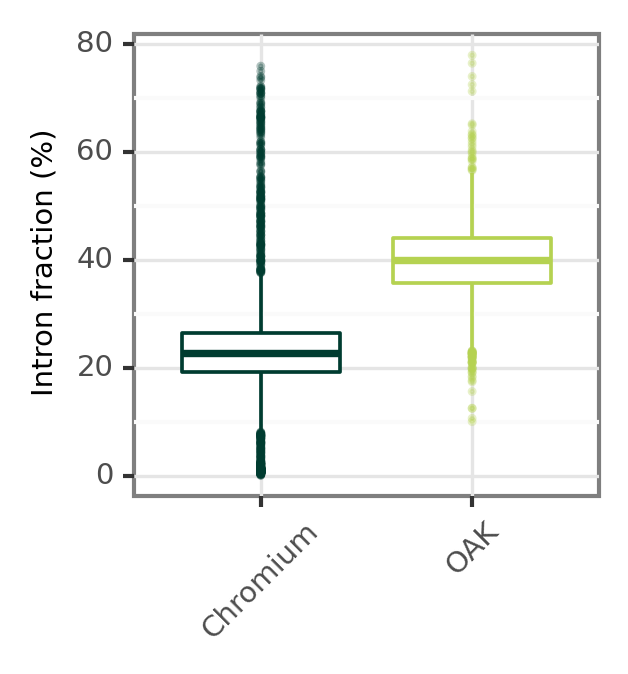

<ggplot: (2932109704695)>

In [11]:
plot=p9.ggplot(data=df_3pRNA_compare[df_3pRNA_compare['call']=='GRCh38'],
               mapping=p9.aes(x='experiment',y='intron_frac',color='experiment')
              )
plot+ p9.geom_boxplot(outlier_alpha=0.3,outlier_size=0.2, show_legend=False) \
+ p9.themes.theme_bw() \
+ p9.theme(figure_size=(2, 2),axis_text_x=p9.element_text(rotation = 45)) \
+ p9.xlab('') \
+ p9.ylab('Intron fraction (%)') \
+ p9.theme(text=p9.element_text(size=7)) \
+ p9.scale_color_manual(values = {'Chromium':'#003C30','OAK':'#B5D251'}) 

In [13]:
plot=p9.ggplot(data=df_3pRNA_compare[df_3pRNA_compare['call']=='GRCh38'],
               mapping=p9.aes(x='experiment',y='intron_frac',color='experiment')
              )
pl=plot+ p9.geom_boxplot(outlier_alpha=0.3,outlier_size=0.2, show_legend=False) \
+ p9.themes.theme_bw() \
+ p9.theme(figure_size=(2, 2),axis_text_x=p9.element_text(rotation = 45)) \
+ p9.xlab('') \
+ p9.ylab('Intron fraction (%)') \
+ p9.theme(text=p9.element_text(size=7)) \
+ p9.scale_color_manual(values = {'Chromium':'#003C30','OAK':'#B5D251'}) 
fig=pl.draw()
fig.set_size_inches(2, 2)
fig.savefig('intron_pct.svg',format='svg',dpi=300,bbox_inches='tight')  

In [14]:
df_3pRNA_compare[df_3pRNA_compare['call']=='GRCh38']

,index,cell_bc,nUMI_exon,nUMI_intron,barcode,GRCh38,mm10,call,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,intron_pct,experiment,intron_frac
0,AAACCCAAGGAAACGA-1,AAACCCAAGGAAACGA,689,7.0,AAACCCAAGGAAACGA-1,673,23,GRCh38,197,5.288267,696.0,6.546785,78.879310,86.063218,100.000000,100.000000,0.010057,Chromium,1.005747
2,AAACCCAAGGGCAAGG-1,AAACCCAAGGGCAAGG,11901,3781.0,AAACCCAAGGGCAAGG-1,15630,52,GRCh38,5081,8.533460,15682.0,9.660333,25.124346,32.750925,40.020406,51.511287,0.241104,Chromium,24.110445
4,AAACCCAAGTGCGCTC-1,AAACCCAAGTGCGCTC,5886,1819.0,AAACCCAAGTGCGCTC-1,7677,28,GRCh38,3246,8.085487,7705.0,8.949755,24.269955,33.147307,41.804023,55.366645,0.236080,Chromium,23.608047
5,AAACCCACAATCGCGC-1,AAACCCACAATCGCGC,16900,5172.0,AAACCCACAATCGCGC-1,22007,65,GRCh38,5906,8.683893,22072.0,10.002111,18.729612,26.313882,34.858644,47.793585,0.234324,Chromium,23.432403
6,AAACCCACACGATTCA-1,AAACCCACACGATTCA,27826,9898.0,AAACCCACACGATTCA-1,37606,118,GRCh38,7519,8.925321,37724.0,10.538078,19.149613,26.717739,34.588061,46.540664,0.262379,Chromium,26.237939
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17731,TTTGTTGCATTGCCGG-1,TTTGTTGCATTGCCGG,2125,2234.0,TTTGTTGCATTGCCGG-1,4242,117,GRCh38,2422,7.792762,4359.0,8.380227,15.049323,21.243404,30.626290,48.680890,0.512503,OAK,51.250287
17732,TTTGTTGGTAATCAAG-1,TTTGTTGGTAATCAAG,3653,1682.0,TTTGTTGGTAATCAAG-1,5297,38,GRCh38,2791,7.934513,5335.0,8.582232,21.349578,27.328960,35.332709,50.234302,0.315276,OAK,31.527648
17733,TTTGTTGGTGACTGAG-1,TTTGTTGGTGACTGAG,3169,1736.0,TTTGTTGGTGACTGAG-1,4856,49,GRCh38,2571,7.852439,4905.0,8.498214,22.854230,28.542304,36.269113,51.416922,0.353925,OAK,35.392457
17736,TTTGTTGGTGTGTTTG-1,TTTGTTGGTGTGTTTG,2062,1652.0,TTTGTTGGTGTGTTTG-1,3632,82,GRCh38,2409,7.787382,3714.0,8.220134,12.439418,18.309101,26.978998,44.534195,0.444803,OAK,44.480345


In [17]:
df_3pRNA_compare[df_3pRNA_compare['call']=='GRCh38'][['barcode','intron_pct','intron_frac','experiment']].to_csv(data_dir+'/SupFig1g.csv',header=True,index=False)